-----

# Lab Exercise

Craigslist is the world's largest collection of used vehicles for sale. GitHub user [@AustinReese](https://github.com/AustinReese/UsedVehicleSearch) scraped Craigslist used car ads to create a dataset of 4.25 million listings. We will be using a subset of around 2 million of these listings.

For this lab, the challenge is to:
  - [ ] Determine which features to include in a model;
  - [ ] Dummy encode or one-hot encode any categorical feature columns;
  - [ ] Perform any data normalization and bucketizing that you believe is necessary;
  - [ ] Perform any data imputation to correct for missing values that you believe is necessary;
  - [ ] Check for outliers and remove any spurious records from the dataset;
  - [ ] Optionally create 1 or more new, engineered feature column(s);
  - [ ] Train a multiple regression to predict vehicle listing price;
  - [ ] Train a binary logistic regression to predict whether vehicle listing price will be greater than $24,500; and
  - [ ] Evaluate both of your models for accuracy

In [1]:
import gdown
import pandas as pd

In [2]:
FILEID="13iHwBTkMXZ8fiOkIAl3oEUM9gdICm_kj"
OUTPUT="/content/vehicles.zip"

url = f"https://drive.google.com/uc?id={FILEID}"
gdown.download(url, OUTPUT, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=13iHwBTkMXZ8fiOkIAl3oEUM9gdICm_kj
From (redirected): https://drive.google.com/uc?id=13iHwBTkMXZ8fiOkIAl3oEUM9gdICm_kj&confirm=t&uuid=ea63678d-91b6-4361-984a-f91e500680c1
To: /content/vehicles.zip
100%|██████████| 273M/273M [00:03<00:00, 76.3MB/s]


'/content/vehicles.zip'

In [3]:
data = pd.read_csv("/content/vehicles.zip")

In [4]:
data.shape

(426880, 26)

In [5]:
data.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [6]:
max_width = max(len(col) for col in data.columns)
for col, item in zip(data.columns, data.loc[1720, :]):
    print(f"{col.rjust(max_width)}:\t {item}")

          id:	 7302548340
         url:	 https://bham.craigslist.org/ctd/d/tuscaloosa-2009-chevrolet-chevy/7302548340.html
      region:	 birmingham
  region_url:	 https://bham.craigslist.org
       price:	 10477
        year:	 2009.0
manufacturer:	 chevrolet
       model:	 colorado
   condition:	 nan
   cylinders:	 nan
        fuel:	 gas
    odometer:	 0.0
title_status:	 clean
transmission:	 automatic
         VIN:	 1GCCS139X98156780
       drive:	 nan
        size:	 nan
        type:	 nan
 paint_color:	 black
   image_url:	 https://images.craigslist.org/00404_jPWmUx686ZUz_09O07m_600x450.jpg
 description:	 Contemporary Automotive address:    3427 Skyland Blvd East Tuscaloosa AL, 35405phone:      ☎ (205) 386-8045 ext 37text:       Text 37 to (205) 386-8045 for more details  link:       http://12284.bestusedcarmarket.com/p/44798890/2/22279277/37  contact:    Keith Vandiver   2009 CHEVROLET COLORADO LT Vehicle InfoStock #: 56780VIN: 1GCCS139X98156780Condition: UsedFuel Efficiency: 18/24D

In [7]:
_remove_cols = [
    "id",
    "url",
    "region",
    "region_url",
    "model",
    "VIN",
    "image_url",
    "description",
    "county",
    "state",
    "lat",
    "long"
]
data = data.drop(_remove_cols, axis=1)

In [8]:
for col, item in zip(data.columns, data.loc[1720, :]):
    print(f"{col.rjust(max_width)}:\t {item}")

       price:	 10477
        year:	 2009.0
manufacturer:	 chevrolet
   condition:	 nan
   cylinders:	 nan
        fuel:	 gas
    odometer:	 0.0
title_status:	 clean
transmission:	 automatic
       drive:	 nan
        size:	 nan
        type:	 nan
 paint_color:	 black
posting_date:	 2021-04-06T08:46:53-0500


In [9]:
data.dtypes

,0
price,int64
year,float64
manufacturer,object
condition,object
cylinders,object
fuel,object
odometer,float64
title_status,object
transmission,object
drive,object


In [10]:
data["cylinders"].unique()

array([nan, '8 cylinders', '6 cylinders', '4 cylinders', '5 cylinders',
       'other', '3 cylinders', '10 cylinders', '12 cylinders'],
      dtype=object)

In [11]:
data["cylinders"] = data["cylinders"].apply(
    lambda x: x.split()[0] if isinstance(x, str) else x
)

In [12]:
data["cylinders"] = pd.to_numeric(data["cylinders"], errors="coerce")
data["cylinders"]

,cylinders
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
426875,6.0
426876,NaN
426877,NaN
426878,6.0


If we have too many values to create new columns via one-hot encoding, we can instead dummy encode our categorical variables. This creates an arbitrary category-to-numeric mapping we can use to create a numeric representation of string data.

To do this, we start by creating a dictionary of key:value pairs that assigns a number to each unique value of our categorical variable:

In [13]:
cat_cols = [
    col
    for col in data.columns
    if str(data[col].dtype) == "object"
]
cat_cols = cat_cols[:-1]
cat_cols

['manufacturer',
 'condition',
 'fuel',
 'title_status',
 'transmission',
 'drive',
 'size',
 'type',
 'paint_color']

In [14]:
for col in cat_cols:
    print(col, len(data[col].unique()))

manufacturer 43
condition 7
fuel 6
title_status 7
transmission 4
drive 4
size 5
type 14
paint_color 13


In [15]:
lookup_dict = {}

for col in cat_cols:
    lookup_dict[col] = {
        key: idx
        for idx, key in enumerate(data[col].unique().tolist())
    }

In [16]:
for col in cat_cols:
    data[col] = data[col].apply(
        lambda x: lookup_dict[col].get(x, None)
    )
    data[col] = pd.to_numeric(data[col], errors="coerce")

In [17]:
data.dtypes

,0
price,int64
year,float64
manufacturer,int64
condition,int64
cylinders,float64
fuel,int64
odometer,float64
title_status,int64
transmission,int64
drive,int64


In [18]:
data[data["posting_date"].notna()]["posting_date"].head()

,posting_date
27,2021-05-04T12:31:18-0500
28,2021-05-04T12:31:08-0500
29,2021-05-04T12:31:25-0500
30,2021-05-04T10:41:31-0500
31,2021-05-03T14:02:03-0500


In [19]:
data["posting_date_parsed"] = pd.to_datetime(
    data["posting_date"].apply(lambda x: x[:10] if type(x) == str else None),
    errors="coerce"
)

In [20]:
data["vehicle_age"] = data["posting_date_parsed"].dt.year - data["year"] + 1

In [21]:
data["miles_per_year"] = data["odometer"] / data["vehicle_age"]

In [22]:
data[data["vehicle_age"].notna()].head()

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,posting_date,posting_date_parsed,vehicle_age,miles_per_year
27,33590,2014.0,1,1,8.0,1,57923.0,1,1,0,0,1,1,2021-05-04T12:31:18-0500,2021-05-04,8.0,7240.375000
28,22590,2010.0,2,1,8.0,1,71229.0,1,1,0,0,1,2,2021-05-04T12:31:08-0500,2021-05-04,12.0,5935.750000
29,39590,2020.0,2,1,8.0,1,19160.0,1,1,0,0,1,3,2021-05-04T12:31:25-0500,2021-05-04,2.0,9580.000000
30,30990,2017.0,3,1,8.0,1,41124.0,1,1,0,0,1,3,2021-05-04T10:41:31-0500,2021-05-04,5.0,8224.800000
31,15000,2013.0,4,2,6.0,1,128000.0,1,2,1,1,2,4,2021-05-03T14:02:03-0500,2021-05-03,9.0,14222.222222


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   price                426880 non-null  int64         
 1   year                 425675 non-null  float64       
 2   manufacturer         426880 non-null  int64         
 3   condition            426880 non-null  int64         
 4   cylinders            247904 non-null  float64       
 5   fuel                 426880 non-null  int64         
 6   odometer             422480 non-null  float64       
 7   title_status         426880 non-null  int64         
 8   transmission         426880 non-null  int64         
 9   drive                426880 non-null  int64         
 10  size                 426880 non-null  int64         
 11  type                 426880 non-null  int64         
 12  paint_color          426880 non-null  int64         
 13  posting_date  

In [24]:
for col in cat_cols:
    print(data.groupby(col).size())

manufacturer
0     17646
1     16785
2     55064
3     34202
4     70985
5     19014
6     19067
7     18342
8      5427
9      6953
10    21269
11    13707
12     8200
13     1946
14     5501
15     6031
16     3374
17     7573
18     4802
19     4220
20      897
21     9495
22     5978
23    10338
24    11817
25    14699
26     3292
27     9345
28     1384
29     8457
30     2113
31       95
32     2376
33     2288
34      792
35      868
36     1090
37     1184
38      153
39       63
40       24
41       21
42        3
dtype: int64
condition
0    174104
1    121456
2    101467
3      6769
4     21178
5      1305
6       601
dtype: int64
fuel
0      3013
1    356209
2     30728
3     30062
4      5170
5      1698
dtype: int64
title_status
0      8242
1    405117
2      7219
3      1422
4      3868
5       814
6       198
dtype: int64
transmission
0      2556
1     62682
2    336524
3     25118
dtype: int64
drive
0    130567
1     58892
2    131904
3    105517
dtype: int64
size
0    

- paint color: remove
- type: keep?
- drive: keep?
- size: keep
- condition: keep?

In [25]:
data = data.drop(["paint_color"], axis=1)

In [26]:
data = data.drop(["year", "posting_date", "posting_date_parsed"], axis=1)

In [27]:
data.head()

,price,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,vehicle_age,miles_per_year
0,6000,0,0,NaN,0,NaN,0,0,0,0,0,NaN,NaN
1,11900,0,0,NaN,0,NaN,0,0,0,0,0,NaN,NaN
2,21000,0,0,NaN,0,NaN,0,0,0,0,0,NaN,NaN
3,1500,0,0,NaN,0,NaN,0,0,0,0,0,NaN,NaN
4,4900,0,0,NaN,0,NaN,0,0,0,0,0,NaN,NaN


In [28]:
data.describe()

,price,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,vehicle_age,miles_per_year
count,4.268800e+05,426880.000000,426880.000000,247904.000000,426880.000000,4.224800e+05,426880.000000,426880.000000,426880.000000,426880.000000,426880.000000,425675.000000,4.213440e+05
mean,7.519903e+04,9.813924,1.029657,5.968685,1.258014,9.804333e+04,1.041396,1.900028,1.497496,0.476352,4.241611,10.764809,inf
std,1.218228e+07,9.165711,1.112973,1.602962,0.683231,2.138815e+05,0.414108,0.468652,1.164512,0.879321,3.561260,9.452120,NaN
min,0.000000e+00,0.000000,0.000000,3.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,5.900000e+03,3.000000,0.000000,4.000000,1.000000,3.770400e+04,1.000000,2.000000,0.000000,0.000000,1.000000,5.000000,5.926750e+03
50%,1.395000e+04,5.000000,1.000000,6.000000,1.000000,8.554800e+04,1.000000,2.000000,2.000000,0.000000,5.000000,9.000000,9.288889e+03
75%,2.648575e+04,16.000000,2.000000,8.000000,1.000000,1.335425e+05,1.000000,2.000000,2.000000,1.000000,8.000000,14.000000,1.283333e+04
max,3.736929e+09,42.000000,6.000000,12.000000,5.000000,1.000000e+07,6.000000,3.000000,3.000000,4.000000,13.000000,122.000000,inf


In [29]:
for val in (0.75, 0.9, 0.95, 0.98, 0.99, 0.995, 0.999, 0.9999):
    print(f"{val}:\t {data['odometer'].quantile(val)}")

0.75:	 133542.5
0.9:	 177377.10000000038
0.95:	 204000.0
0.98:	 243262.41999999998
0.99:	 280000.0
0.995:	 350753.94499999424
0.999:	 1111111.0
0.9999:	 10000000.0


In [30]:
data = data.loc[data["odometer"] <= 280000, :]

<Axes: ylabel='Frequency'>

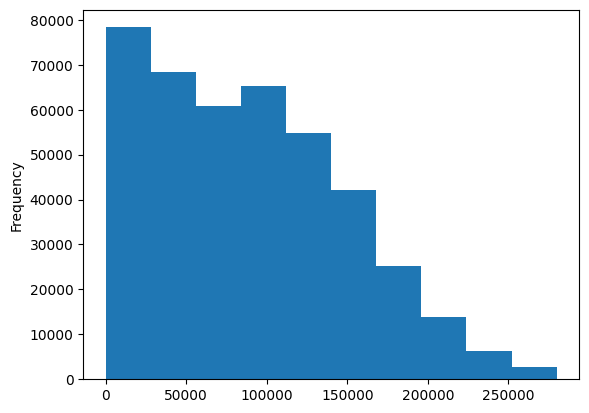

In [31]:
data["odometer"].plot.hist()

In [32]:
data.describe()

,price,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,vehicle_age,miles_per_year
count,4.183140e+05,418314.000000,418314.000000,244008.000000,418314.000000,418314.000000,418314.000000,418314.000000,418314.000000,418314.000000,418314.000000,417194.000000,4.171940e+05
mean,7.119260e+04,9.870035,1.030699,5.962608,1.255602,89669.283349,1.042133,1.899468,1.502582,0.477278,4.259666,10.679384,inf
std,1.211243e+07,9.179445,1.113046,1.602149,0.677472,60573.607672,0.409317,0.460839,1.164360,0.879917,3.561270,9.358448,NaN
min,0.000000e+00,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,5.995000e+03,3.000000,0.000000,4.000000,1.000000,37229.250000,1.000000,2.000000,0.000000,0.000000,1.000000,5.000000,5.888500e+03
50%,1.399500e+04,6.000000,1.000000,6.000000,1.000000,84646.000000,1.000000,2.000000,2.000000,0.000000,5.000000,8.000000,9.226598e+03
75%,2.659000e+04,16.000000,2.000000,8.000000,1.000000,131900.000000,1.000000,2.000000,2.000000,1.000000,8.000000,14.000000,1.271233e+04
max,3.736929e+09,42.000000,6.000000,12.000000,5.000000,280000.000000,6.000000,3.000000,3.000000,4.000000,13.000000,122.000000,inf


<Axes: ylabel='Frequency'>

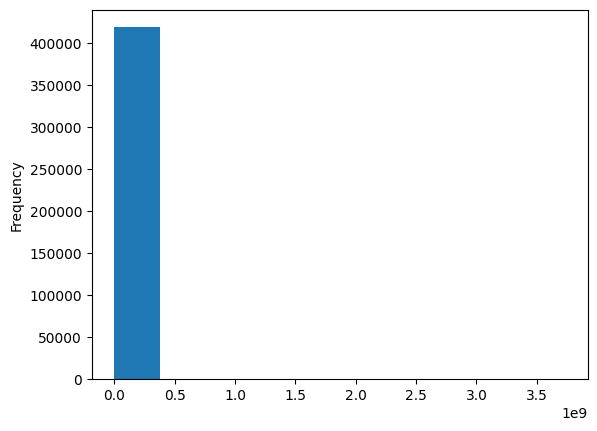

In [33]:
data["price"].plot.hist()

In [34]:
for val in (0.75, 0.9, 0.95, 0.98, 0.99, 0.995, 0.999, 0.9995, 0.9998, 0.9999):
    print(f"{val}:\t {data['price'].quantile(val)}")

0.75:	 26590.0
0.9:	 37590.0
0.95:	 44500.0
0.98:	 56750.0
0.99:	 66992.0
0.995:	 76995.0
0.999:	 119995.0
0.9995:	 147671.35000003618
0.9998:	 259007.2000000556
0.9999:	 1234567.0


In [35]:
data = data.loc[data["price"] <= 150000, :]

<Axes: ylabel='Frequency'>

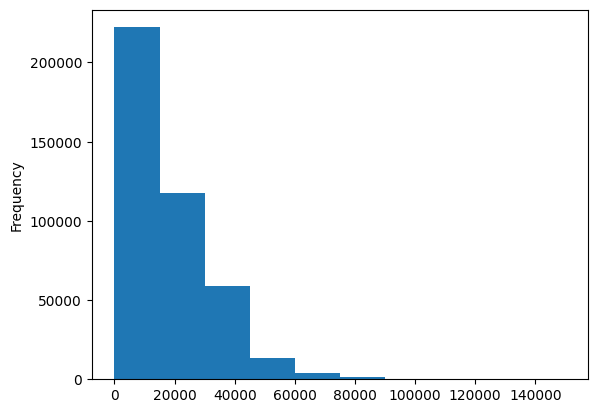

In [36]:
data["price"].plot.hist()

In [37]:
data.columns

Index(['price', 'manufacturer', 'condition', 'cylinders', 'fuel', 'odometer',
       'title_status', 'transmission', 'drive', 'size', 'type', 'vehicle_age',
       'miles_per_year'],
      dtype='object')

In [38]:
data.describe()

,price,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,vehicle_age,miles_per_year
count,418131.000000,418131.000000,418131.000000,243898.000000,418131.000000,418131.000000,418131.000000,418131.000000,418131.000000,418131.000000,418131.000000,417011.000000,4.170110e+05
mean,17523.171817,9.869120,1.030679,5.961529,1.255561,89688.534988,1.041970,1.899481,1.502857,0.477145,4.260055,10.678205,inf
std,15182.959316,9.177658,1.112865,1.601173,0.677484,60568.633310,0.408659,0.460776,1.164327,0.879723,3.561192,9.351968,NaN
min,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,5995.000000,3.000000,0.000000,4.000000,1.000000,37255.000000,1.000000,2.000000,0.000000,0.000000,1.000000,5.000000,5.889750e+03
50%,13995.000000,6.000000,1.000000,6.000000,1.000000,84661.000000,1.000000,2.000000,2.000000,0.000000,5.000000,8.000000,9.228400e+03
75%,26590.000000,16.000000,2.000000,8.000000,1.000000,131917.500000,1.000000,2.000000,2.000000,1.000000,8.000000,14.000000,1.271395e+04
max,150000.000000,42.000000,6.000000,12.000000,5.000000,280000.000000,6.000000,3.000000,3.000000,4.000000,13.000000,122.000000,inf


In [39]:
import numpy as np

data["miles_per_year"] = data["miles_per_year"].replace([np.inf, -np.inf], np.nan)
data["miles_per_year"] = data["miles_per_year"].fillna(0)

In [40]:
data.describe()

,price,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,vehicle_age,miles_per_year
count,418131.000000,418131.000000,418131.000000,243898.000000,418131.000000,418131.000000,418131.000000,418131.000000,418131.000000,418131.000000,418131.000000,417011.000000,418131.000000
mean,17523.171817,9.869120,1.030679,5.961529,1.255561,89688.534988,1.041970,1.899481,1.502857,0.477145,4.260055,10.678205,9640.222786
std,15182.959316,9.177658,1.112865,1.601173,0.677484,60568.633310,0.408659,0.460776,1.164327,0.879723,3.561192,9.351968,5686.013375
min,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5995.000000,3.000000,0.000000,4.000000,1.000000,37255.000000,1.000000,2.000000,0.000000,0.000000,1.000000,5.000000,5857.142857
50%,13995.000000,6.000000,1.000000,6.000000,1.000000,84661.000000,1.000000,2.000000,2.000000,0.000000,5.000000,8.000000,9206.250000
75%,26590.000000,16.000000,2.000000,8.000000,1.000000,131917.500000,1.000000,2.000000,2.000000,1.000000,8.000000,14.000000,12697.901786
max,150000.000000,42.000000,6.000000,12.000000,5.000000,280000.000000,6.000000,3.000000,3.000000,4.000000,13.000000,122.000000,240000.000000


In [41]:
data = data.dropna(how="any")

In [42]:
from sklearn.linear_model import LinearRegression

lin_mod = LinearRegression().fit(
    data.loc[:, data.columns!="price"],
    data["price"]
)

lin_mod.coef_

array([-4.10885606e+01,  8.94568532e+01,  2.55994142e+03,  3.44174508e+03,
       -1.25454142e-01, -5.79390020e+02, -1.68996879e+03, -6.94317361e+02,
       -3.37797222e+02, -3.22881225e+02, -1.73822059e+02,  3.73783165e-01])

In [43]:
r_squared = lin_mod.score(
    data.loc[:, data.columns!="price"],
    data["price"]
)

print('R^2 = {:2.2%}'.format(r_squared))

R^2 = 41.04%


In [44]:
preds = lin_mod.predict(data.loc[:, data.columns!="price"])

## Mean Absolute Error

On average, how far off from ground truth is our predicted value (in the same unit of measure as our Y variable)

In [45]:
np.sqrt(np.mean((data["price"] - preds) ** 2))

np.float64(11333.409581152317)

In [46]:
data["price"].describe()

,price
count,242797.000000
mean,16518.608615
std,14760.064705
min,0.000000
25%,5600.000000
50%,12000.000000
75%,24995.000000
max,150000.000000
